# Grocery Dataset Descriptive Analysis

This notebook performs a comprehensive descriptive analysis of the grocery dataset, including statistical summaries, categorical analysis, and discount patterns.

## 1. Load and Import Libraries
Import necessary libraries including pandas, numpy, and matplotlib for data manipulation and visualization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load the Dataset
Load the grocery_dataset.csv file into a pandas DataFrame and display the first few rows to understand the data structure.

In [3]:
df = pd.read_csv('grocery_dataset.csv')
print("Dataset shape:", df.shape)
print("\nFirst 5 rows of the dataset:")
df.head()

Dataset shape: (144, 8)

First 5 rows of the dataset:


,Product Name,Category,Month,Quantity,Original Price,Discounted Price,Seasonal Availability Flag,Health Tag
0,Apple,Fruits,January,4,240,210,Yes,Healthy
1,Mango,Fruits,January,3,300,260,No,Healthy
2,Banana,Fruits,January,6,120,100,Yes,Healthy
3,Orange,Fruits,January,5,200,180,Yes,Healthy
4,Potato,Vegetables,January,5,150,130,Yes,Healthy


## 3. Display Basic Dataset Information
Display dataset shape, column names, data types, and check for missing values using info() and isnull() methods.

In [4]:
print("Dataset Info:")
df.info()
print("\n" + "="*50)
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*50)
print("Column Names and Data Types:")
print(df.dtypes)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Product Name                144 non-null    object
 1   Category                    144 non-null    object
 2   Month                       144 non-null    object
 3   Quantity                    144 non-null    int64 
 4   Original Price              144 non-null    int64 
 5   Discounted Price            144 non-null    int64 
 6   Seasonal Availability Flag  84 non-null     object
 7   Health Tag                  132 non-null    object
dtypes: int64(3), object(5)
memory usage: 9.1+ KB

Missing Values:
Product Name                   0
Category                       0
Month                          0
Quantity                       0
Original Price                 0
Discounted Price               0
Seasonal Availability Flag    60
Health Tag              

## 4. Generate Descriptive Statistics
Calculate descriptive statistics (mean, median, std, min, max) for numerical columns like Quantity, Original Price, and Discounted Price using describe().

In [5]:
print("Descriptive Statistics for Numerical Columns:")
print(df.describe())
print("\n" + "="*50)
print("Additional Statistics:")
print(f"Quantity - Mean: {df['Quantity'].mean():.2f}, Median: {df['Quantity'].median():.2f}")
print(f"Original Price - Mean: {df['Original Price'].mean():.2f}, Median: {df['Original Price'].median():.2f}")
print(f"Discounted Price - Mean: {df['Discounted Price'].mean():.2f}, Median: {df['Discounted Price'].median():.2f}")

Descriptive Statistics for Numerical Columns:
         Quantity  Original Price  Discounted Price
count  144.000000      144.000000        144.000000
mean     4.326389      182.986111        161.527778
std      2.147791       76.369362         69.925729
min      1.000000       80.000000         70.000000
25%      3.000000      120.000000         95.000000
50%      4.000000      180.000000        165.000000
75%      5.000000      242.500000        215.000000
max     10.000000      300.000000        270.000000

Additional Statistics:
Quantity - Mean: 4.33, Median: 4.00
Original Price - Mean: 182.99, Median: 180.00
Discounted Price - Mean: 161.53, Median: 165.00


## 5. Analyze Categorical Variables
Analyze the frequency distribution of categorical variables such as Product Name, Category, and Month using value_counts().

Product Name Distribution:
Product Name
Apple         12
Mango         12
Banana        12
Orange        12
Potato        12
Tomato        12
Onion         12
Rice          12
Milk          12
Bread         12
Detergent      6
Shampoo        6
Cold Drink     6
Biscuits       5
Chips          1
Name: count, dtype: int64

Category Distribution:
Category
Fruits           48
Vegetables       36
Grains           12
Dairy            12
Bakery           12
Snacks            6
Cleaning          6
Beverages         6
Personal Care     6
Name: count, dtype: int64

Month Distribution:
Month
April        12
August       12
December     12
February     12
January      12
July         12
June         12
March        12
May          12
November     12
October      12
September    12
Name: count, dtype: int64


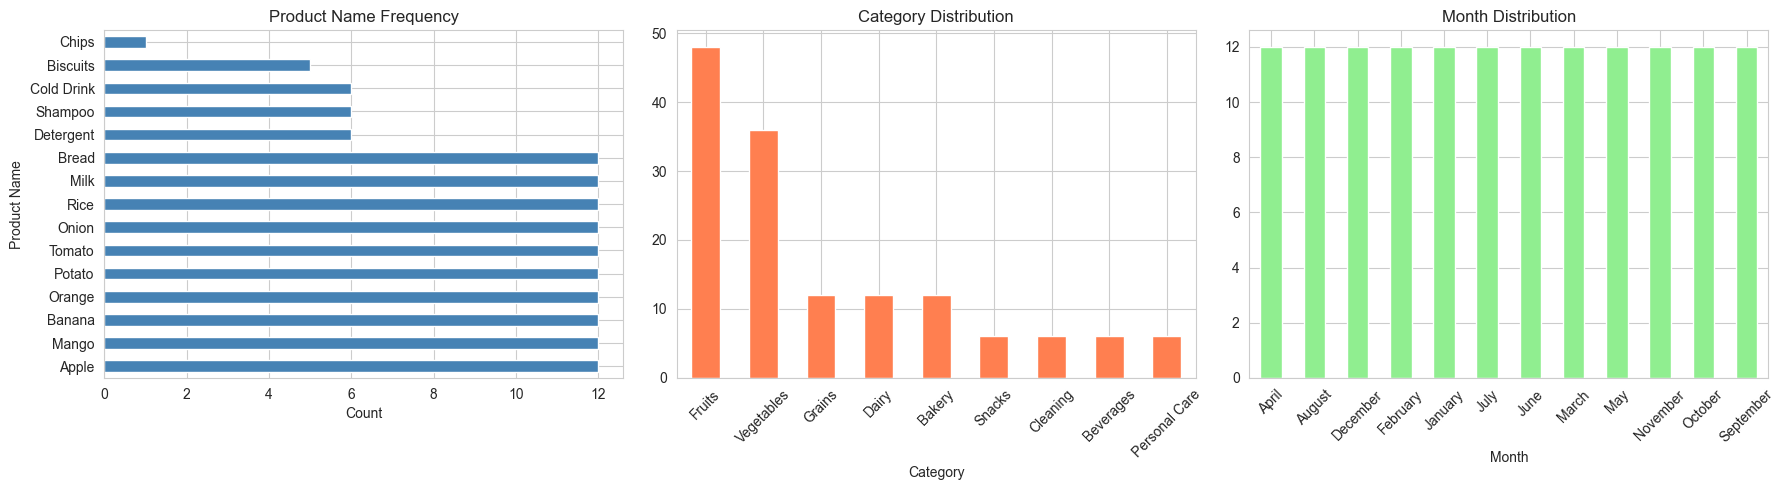

In [6]:
print("Product Name Distribution:")
print(df['Product Name'].value_counts())
print("\n" + "="*50)
print("Category Distribution:")
print(df['Category'].value_counts())
print("\n" + "="*50)
print("Month Distribution:")
print(df['Month'].value_counts().sort_index())

# Create visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df['Product Name'].value_counts().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Product Name Frequency')
axes[0].set_xlabel('Count')

df['Category'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Category Distribution')
axes[1].set_xlabel('Category')
axes[1].tick_params(axis='x', rotation=45)

df['Month'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='lightgreen')
axes[2].set_title('Month Distribution')
axes[2].set_xlabel('Month')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Calculate Discount Analysis
Calculate the discount amount and discount percentage for each product, then analyze average discounts by category.

Discount Analysis:
Average Discount Amount: ₹21.46
Average Discount Percentage: 12.40%
Total Discount Amount: ₹3090.00

Average Discount by Category:
               Discount Amount  Discount Percentage  Count
Category                                                  
Bakery                    10.0            12.500000     12
Beverages                 10.0             6.250000      6
Cleaning                  20.0             9.090000      6
Dairy                     20.0             8.000000     12
Fruits                    27.5            13.125000     48
Grains                    30.0            10.000000     12
Personal Care             20.0             9.090000      6
Snacks                     5.0             5.466667      6
Vegetables                20.0            16.943333     36


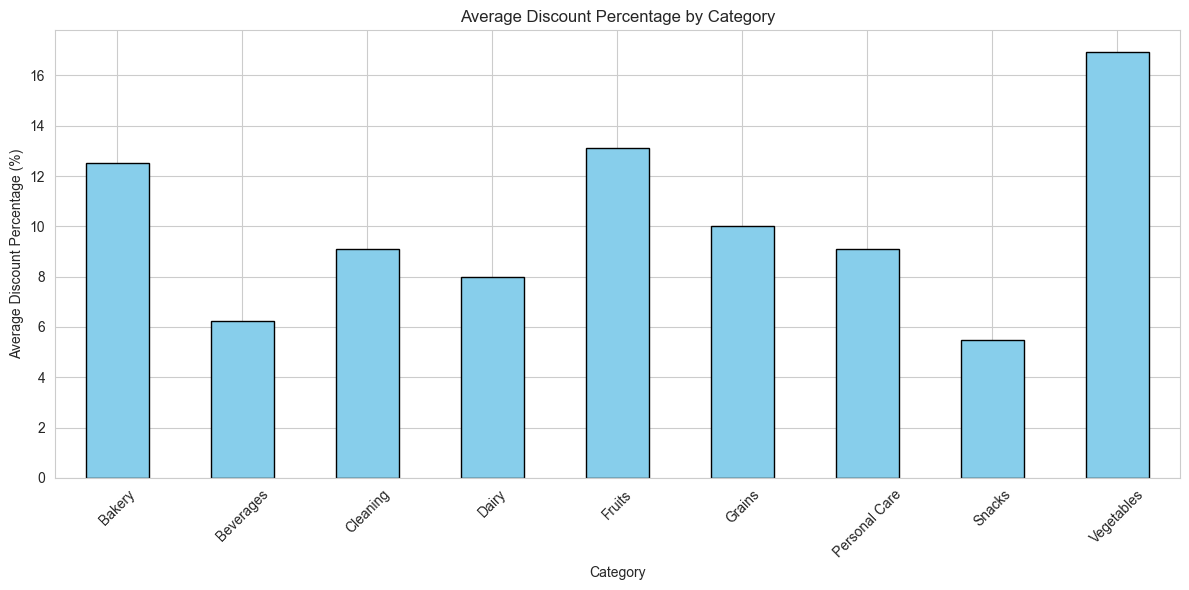

In [7]:
# Calculate discount metrics
df['Discount Amount'] = df['Original Price'] - df['Discounted Price']
df['Discount Percentage'] = (df['Discount Amount'] / df['Original Price'] * 100).round(2)

print("Discount Analysis:")
print(f"Average Discount Amount: ₹{df['Discount Amount'].mean():.2f}")
print(f"Average Discount Percentage: {df['Discount Percentage'].mean():.2f}%")
print(f"Total Discount Amount: ₹{df['Discount Amount'].sum():.2f}")
print("\n" + "="*50)
print("Average Discount by Category:")
discount_by_category = df.groupby('Category').agg({
    'Discount Amount': 'mean',
    'Discount Percentage': 'mean',
    'Product Name': 'count'
}).rename(columns={'Product Name': 'Count'})
print(discount_by_category)

# Visualization
plt.figure(figsize=(12, 6))
discount_by_category['Discount Percentage'].plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average Discount Percentage by Category')
plt.xlabel('Category')
plt.ylabel('Average Discount Percentage (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Explore Seasonal Availability Patterns
Analyze the distribution of Seasonal Availability Flag across different categories and months to identify seasonal trends.

Seasonal Availability Flag Distribution:
Seasonal Availability Flag
NaN    60
Yes    43
No     41
Name: count, dtype: int64

Seasonal Availability by Category:
Seasonal Availability Flag  No  Yes
Category                           
Fruits                      27   21
Vegetables                  14   22

Seasonal Availability by Month:
Seasonal Availability Flag  No  Yes
Month                              
April                        4    3
August                       5    2
December                     1    6
February                     2    5
January                      1    6
July                         5    2
June                         5    2
March                        3    4
May                          4    3
November                     2    5
October                      4    3
September                    5    2


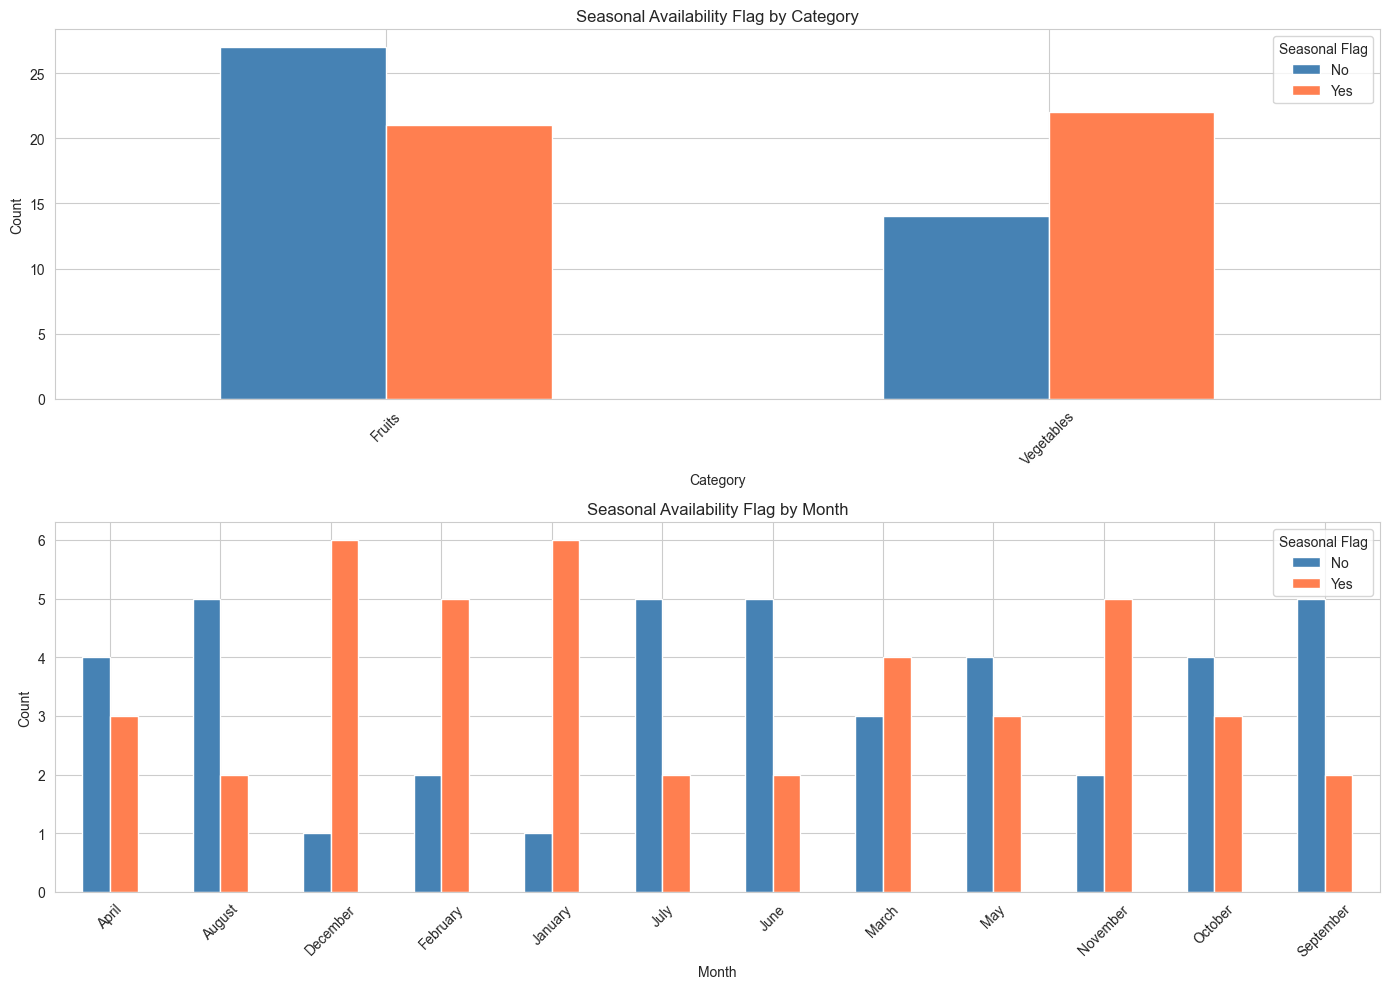

In [8]:
print("Seasonal Availability Flag Distribution:")
print(df['Seasonal Availability Flag'].value_counts(dropna=False))
print("\n" + "="*50)
print("Seasonal Availability by Category:")
seasonal_by_category = pd.crosstab(df['Category'], df['Seasonal Availability Flag'])
print(seasonal_by_category)
print("\n" + "="*50)
print("Seasonal Availability by Month:")
seasonal_by_month = pd.crosstab(df['Month'], df['Seasonal Availability Flag'])
print(seasonal_by_month)

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Seasonal by Category
seasonal_by_category.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral', 'lightgreen'])
axes[0].set_title('Seasonal Availability Flag by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].legend(title='Seasonal Flag')
axes[0].tick_params(axis='x', rotation=45)

# Seasonal by Month
seasonal_by_month.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral', 'lightgreen'])
axes[1].set_title('Seasonal Availability Flag by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Count')
axes[1].legend(title='Seasonal Flag')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 8. Health Tag Distribution
Analyze the distribution of Health Tag values (Healthy, Junk, NA) and their relationship with product categories.

Health Tag Distribution:
Health Tag
Healthy    108
Junk        24
NaN         12
Name: count, dtype: int64

Health Tag by Category:
Health Tag  Healthy  Junk
Category                 
Bakery            0    12
Beverages         0     6
Dairy            12     0
Fruits           48     0
Grains           12     0
Snacks            0     6
Vegetables       36     0


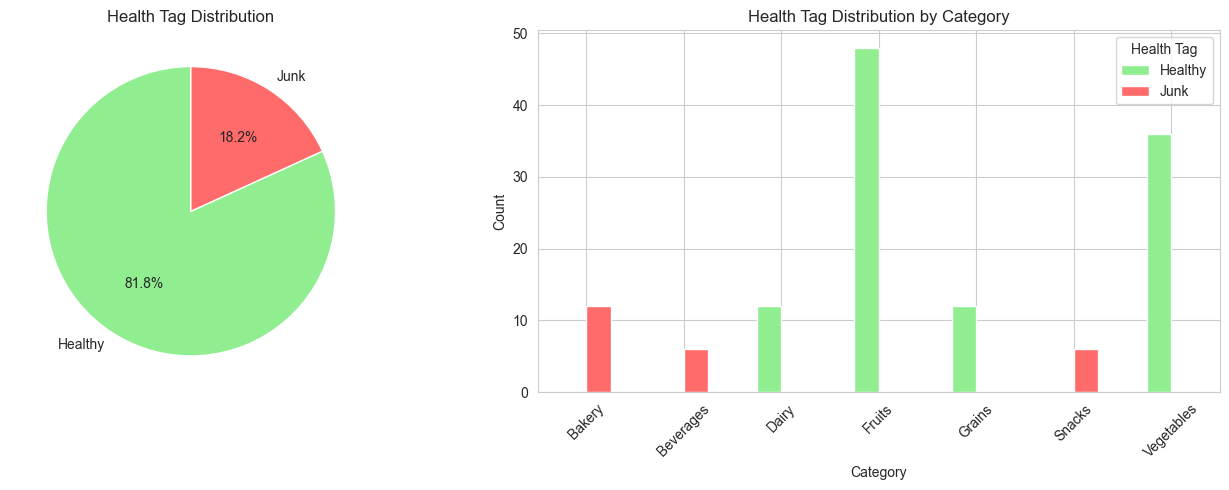


Summary Statistics:
Total Records: 144
Unique Products: 15
Unique Categories: 9
Months Covered: 12
Total Revenue (Original Prices): ₹120230.00
Total Revenue (Discounted Prices): ₹106645.00
Total Discount Given: ₹13585.00


In [9]:
print("Health Tag Distribution:")
print(df['Health Tag'].value_counts(dropna=False))
print("\n" + "="*50)
print("Health Tag by Category:")
health_by_category = pd.crosstab(df['Category'], df['Health Tag'])
print(health_by_category)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart for Health Tag Distribution
health_counts = df['Health Tag'].value_counts()
colors = ['#90EE90', '#FF6B6B', '#C0C0C0']
axes[0].pie(health_counts, labels=health_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[0].set_title('Health Tag Distribution')

# Bar chart for Health Tag by Category
health_by_category.plot(kind='bar', ax=axes[1], color=['#90EE90', '#FF6B6B', '#C0C0C0'])
axes[1].set_title('Health Tag Distribution by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')
axes[1].legend(title='Health Tag')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("Summary Statistics:")
print(f"Total Records: {len(df)}")
print(f"Unique Products: {df['Product Name'].nunique()}")
print(f"Unique Categories: {df['Category'].nunique()}")
print(f"Months Covered: {df['Month'].nunique()}")
print(f"Total Revenue (Original Prices): ₹{(df['Quantity'] * df['Original Price']).sum():.2f}")
print(f"Total Revenue (Discounted Prices): ₹{(df['Quantity'] * df['Discounted Price']).sum():.2f}")
print(f"Total Discount Given: ₹{(df['Quantity'] * df['Discount Amount']).sum():.2f}")

## 9. K-Means Clustering Analysis
Apply K-means clustering machine learning algorithm to segment products based on numerical features.

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select numerical features for clustering
clustering_features = ['Quantity', 'Original Price', 'Discounted Price', 'Discount Amount', 'Discount Percentage']
X = df[clustering_features].copy()

# Standardize the features (important for K-means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features selected for clustering:")
print(clustering_features)
print(f"\nData shape for clustering: {X_scaled.shape}")
print("Data has been standardized using StandardScaler")

Features selected for clustering:
['Quantity', 'Original Price', 'Discounted Price', 'Discount Amount', 'Discount Percentage']

Data shape for clustering: (144, 5)
Data has been standardized using StandardScaler


### 9.1 Determine Optimal Number of Clusters (Elbow Method)
Use the elbow method to find the optimal number of clusters by analyzing the inertia (within-cluster sum of squares).

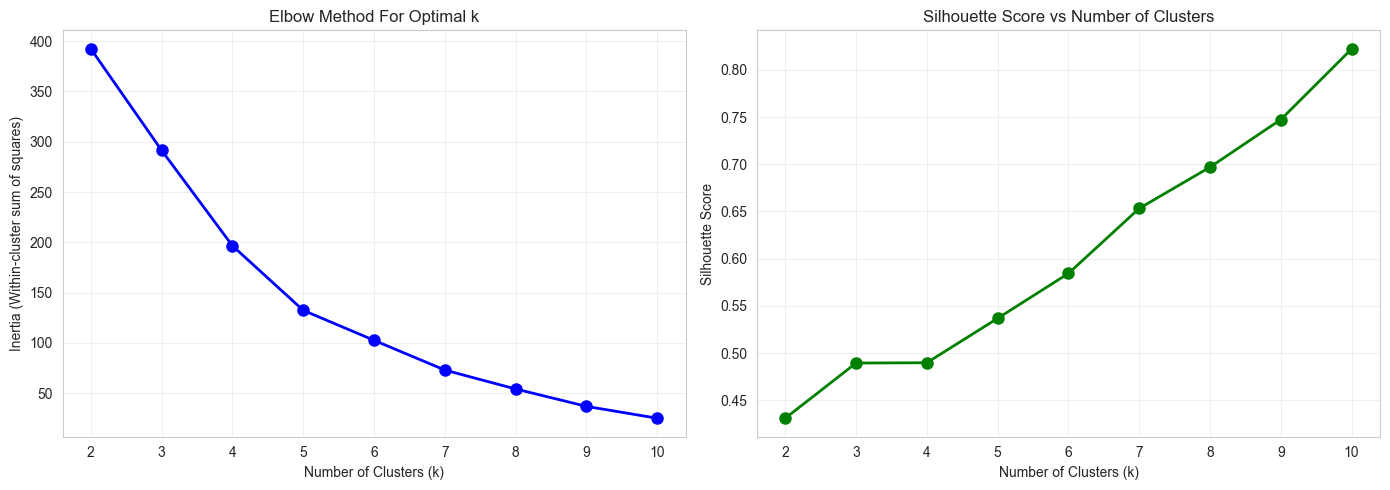

Inertia values for different k:
k=2: Inertia=392.22
k=3: Inertia=291.34
k=4: Inertia=196.54
k=5: Inertia=132.42
k=6: Inertia=102.64
k=7: Inertia=73.08
k=8: Inertia=54.28
k=9: Inertia=37.02
k=10: Inertia=25.22

Silhouette scores for different k:
k=2: Silhouette Score=0.4309
k=3: Silhouette Score=0.4894
k=4: Silhouette Score=0.4897
k=5: Silhouette Score=0.5367
k=6: Silhouette Score=0.5843
k=7: Silhouette Score=0.6533
k=8: Silhouette Score=0.6970
k=9: Silhouette Score=0.7474
k=10: Silhouette Score=0.8222


In [11]:
# Elbow method to find optimal number of clusters
inertias = []
silhouette_scores = []
K_range = range(2, 11)

from sklearn.metrics import silhouette_score

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)')
axes[0].set_title('Elbow Method For Optimal k')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs Number of Clusters')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Inertia values for different k:")
for k, inertia in zip(K_range, inertias):
    print(f"k={k}: Inertia={inertia:.2f}")
    
print("\nSilhouette scores for different k:")
for k, score in zip(K_range, silhouette_scores):
    print(f"k={k}: Silhouette Score={score:.4f}")

### 9.2 Apply K-Means Clustering with Optimal k
Based on the elbow method, we'll apply K-means with k=3 clusters to segment the products.

In [12]:
# Apply K-means with optimal k=3
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"K-Means Clustering with k={optimal_k}")
print(f"Inertia: {kmeans.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X_scaled, df['Cluster']):.4f}")
print(f"\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())
print(f"\nCluster centers (original scale):")
cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(cluster_centers_original, columns=clustering_features)
print(centers_df)

K-Means Clustering with k=3
Inertia: 291.34
Silhouette Score: 0.4894

Cluster distribution:
Cluster
0    12
1    72
2    60
Name: count, dtype: int64

Cluster centers (original scale):
    Quantity  Original Price  Discounted Price  Discount Amount  \
0  10.000000      250.000000        230.000000            20.00   
1   3.902778      114.305556         98.055556            16.25   
2   3.700000      252.000000        224.000000            28.00   

   Discount Percentage  
0             8.000000  
1            14.309722  
2            10.984000  


### 9.3 Visualize Clusters
Visualize the clusters using different feature combinations and 3D scatter plots.

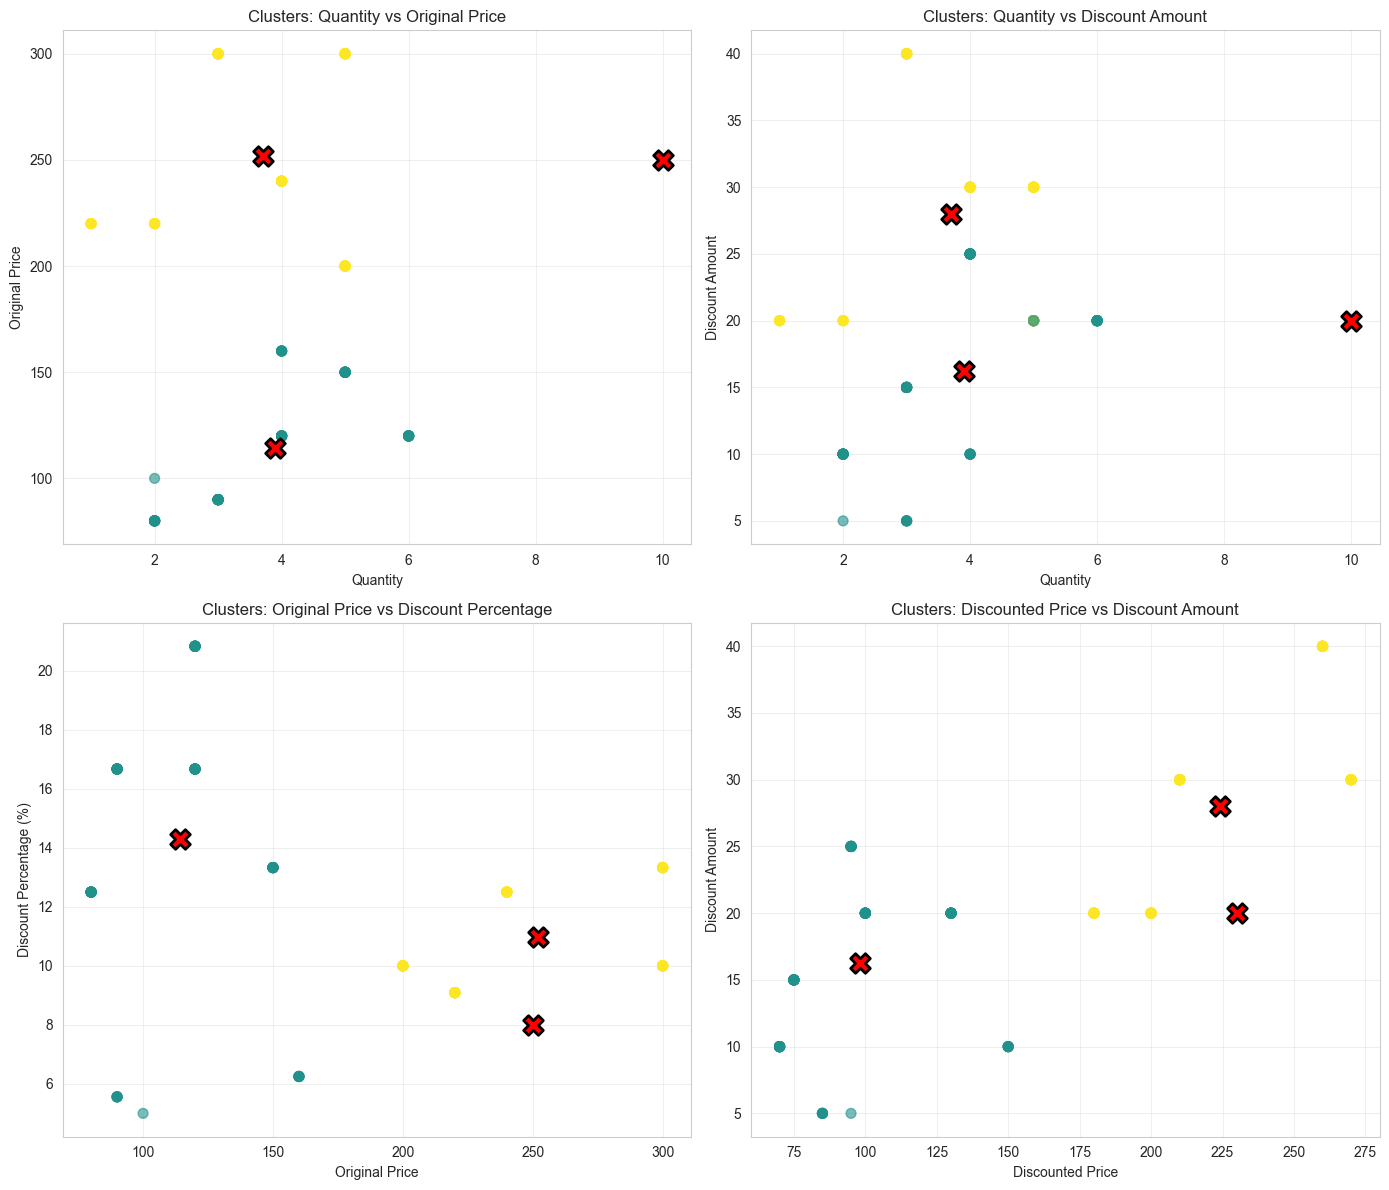

Red X markers represent cluster centers


In [13]:
# Visualize clusters in 2D using different feature pairs
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
colors = ['red', 'blue', 'green']

# Plot 1: Quantity vs Original Price
scatter1 = axes[0, 0].scatter(df['Quantity'], df['Original Price'], 
                               c=df['Cluster'], cmap='viridis', s=50, alpha=0.6)
axes[0, 0].scatter(cluster_centers_original[:, 0], cluster_centers_original[:, 1], 
                    c='red', marker='X', s=200, edgecolors='black', linewidths=2)
axes[0, 0].set_xlabel('Quantity')
axes[0, 0].set_ylabel('Original Price')
axes[0, 0].set_title('Clusters: Quantity vs Original Price')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Discount Amount vs Quantity
scatter2 = axes[0, 1].scatter(df['Quantity'], df['Discount Amount'], 
                               c=df['Cluster'], cmap='viridis', s=50, alpha=0.6)
axes[0, 1].scatter(cluster_centers_original[:, 0], cluster_centers_original[:, 3], 
                    c='red', marker='X', s=200, edgecolors='black', linewidths=2)
axes[0, 1].set_xlabel('Quantity')
axes[0, 1].set_ylabel('Discount Amount')
axes[0, 1].set_title('Clusters: Quantity vs Discount Amount')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Original Price vs Discount Percentage
scatter3 = axes[1, 0].scatter(df['Original Price'], df['Discount Percentage'], 
                               c=df['Cluster'], cmap='viridis', s=50, alpha=0.6)
axes[1, 0].scatter(cluster_centers_original[:, 1], cluster_centers_original[:, 4], 
                    c='red', marker='X', s=200, edgecolors='black', linewidths=2)
axes[1, 0].set_xlabel('Original Price')
axes[1, 0].set_ylabel('Discount Percentage (%)')
axes[1, 0].set_title('Clusters: Original Price vs Discount Percentage')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Discounted Price vs Discount Amount
scatter4 = axes[1, 1].scatter(df['Discounted Price'], df['Discount Amount'], 
                               c=df['Cluster'], cmap='viridis', s=50, alpha=0.6)
axes[1, 1].scatter(cluster_centers_original[:, 2], cluster_centers_original[:, 3], 
                    c='red', marker='X', s=200, edgecolors='black', linewidths=2)
axes[1, 1].set_xlabel('Discounted Price')
axes[1, 1].set_ylabel('Discount Amount')
axes[1, 1].set_title('Clusters: Discounted Price vs Discount Amount')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Red X markers represent cluster centers")

### 9.4 Cluster Characteristics Analysis
Analyze the characteristics of each cluster to understand what segments they represent.

In [14]:
# Analyze characteristics of each cluster
for cluster in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster]
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster} - Size: {len(cluster_data)} records")
    print(f"{'='*60}")
    print(f"Average Quantity: {cluster_data['Quantity'].mean():.2f}")
    print(f"Average Original Price: ₹{cluster_data['Original Price'].mean():.2f}")
    print(f"Average Discounted Price: ₹{cluster_data['Discounted Price'].mean():.2f}")
    print(f"Average Discount Amount: ₹{cluster_data['Discount Amount'].mean():.2f}")
    print(f"Average Discount Percentage: {cluster_data['Discount Percentage'].mean():.2f}%")
    print(f"\nTop Products in this cluster:")
    print(cluster_data['Product Name'].value_counts().head())
    print(f"\nCategory Distribution:")
    print(cluster_data['Category'].value_counts())
    print(f"\nHealth Tag Distribution:")
    print(cluster_data['Health Tag'].value_counts(dropna=False))


CLUSTER 0 - Size: 12 records
Average Quantity: 10.00
Average Original Price: ₹250.00
Average Discounted Price: ₹230.00
Average Discount Amount: ₹20.00
Average Discount Percentage: 8.00%

Top Products in this cluster:
Product Name
Milk    12
Name: count, dtype: int64

Category Distribution:
Category
Dairy    12
Name: count, dtype: int64

Health Tag Distribution:
Health Tag
Healthy    12
Name: count, dtype: int64

CLUSTER 1 - Size: 72 records
Average Quantity: 3.90
Average Original Price: ₹114.31
Average Discounted Price: ₹98.06
Average Discount Amount: ₹16.25
Average Discount Percentage: 14.31%

Top Products in this cluster:
Product Name
Banana    12
Potato    12
Tomato    12
Onion     12
Bread     12
Name: count, dtype: int64

Category Distribution:
Category
Vegetables    36
Fruits        12
Bakery        12
Snacks         6
Beverages      6
Name: count, dtype: int64

Health Tag Distribution:
Health Tag
Healthy    48
Junk       24
Name: count, dtype: int64

CLUSTER 2 - Size: 60 record

### 9.5 Cluster Comparison Heatmap
Visualize cluster characteristics using a heatmap for easy comparison.

Cluster Summary:
   Cluster  Size  Avg Quantity  Avg Original Price  Avg Discount %  \
0        0    12     10.000000          250.000000        8.000000   
1        1    72      3.902778          114.305556       14.309722   
2        2    60      3.700000          252.000000       10.984000   

   Avg Discounted Price  
0            230.000000  
1             98.055556  
2            224.000000  


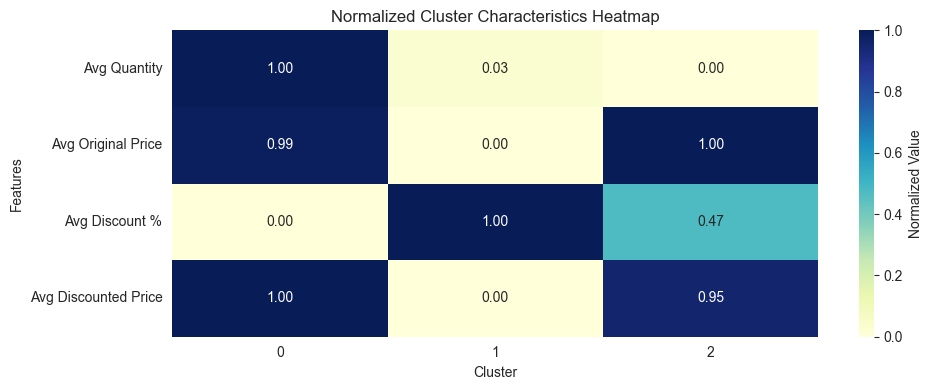

In [15]:
# Create a summary dataframe for cluster comparison
cluster_summary = pd.DataFrame()

for cluster in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster]
    summary = {
        'Cluster': cluster,
        'Size': len(cluster_data),
        'Avg Quantity': cluster_data['Quantity'].mean(),
        'Avg Original Price': cluster_data['Original Price'].mean(),
        'Avg Discount %': cluster_data['Discount Percentage'].mean(),
        'Avg Discounted Price': cluster_data['Discounted Price'].mean()
    }
    cluster_summary = pd.concat([cluster_summary, pd.DataFrame([summary])], ignore_index=True)

print("Cluster Summary:")
print(cluster_summary)

# Normalize for heatmap visualization
cluster_summary_normalized = cluster_summary.set_index('Cluster')[['Avg Quantity', 'Avg Original Price', 'Avg Discount %', 'Avg Discounted Price']]
cluster_summary_normalized = (cluster_summary_normalized - cluster_summary_normalized.min()) / (cluster_summary_normalized.max() - cluster_summary_normalized.min())

plt.figure(figsize=(10, 4))
sns.heatmap(cluster_summary_normalized.T, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Normalized Value'})
plt.title('Normalized Cluster Characteristics Heatmap')
plt.xlabel('Cluster')
plt.ylabel('Features')
plt.tight_layout()
plt.show()